### Upload Your Files to Colab

In [ ]:
from google.colab import files

uploaded = files.upload()  # Manually upload JSON + images


Saving news_prompts_refined.json to news_prompts_refined.json


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls "/content/drive/MyDrive/emoji_dataset/"


ls: cannot access '/content/drive/MyDrive/emoji_dataset/': No such file or directory


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!ls "/content/drive/MyDrive/model_tuning/DATASETS/"


images_extracted


In [ ]:
!ls "/content/drive/MyDrive/"


 AIP_Project		    'In-class Application Exercise 3.gdoc'
'Canada Documents'	    'LatentBridge-Applicant Form for Freshers (3).docx'
'Colab Notebooks'	    'Maths Assesment 3.gdoc'
'Data Science with Python'   model_tuning
'Dharmik .gdoc'		    'My_Finding '
'DHARMIK_RESUME (1).pdf'    'other document'
'DHARMIK_RESUME (2).pdf'    'pqdqBdYHmqF4ZvYXd651yA==.pdf'
 DHARMIK_RESUME.gdoc	     Resume_Dharmik.pdf
 DHARMIK_RESUME.pdf	    'Simplilearn Important Document'
 ICAE#4.xlsx		     SQL.pdf


In [ ]:
!ls "/content/drive/MyDrive/AIP_Project"


'Detailed Report.gdoc'			  results  'week 5'	       'Week 6'
'Report: Stable Diffusion Project.gdoc'   SG2ADA    Week5_Update.gdoc


In [ ]:
!ls "/content/drive/MyDrive/AIP_Project/Week 6"

'Fine Tune '	    'Stable Diffusion 2'      'Word-Based Emoji conversion .gdoc'
'model_tuning  '    'Transfer Learning.gdoc'
'Stable Diffusion'   Untitled0.ipynb


In [2]:
!ls "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS"

emojis_data_description.json  images.zip		      preprocessed_text_fixed.json
images_extracted	      preprocessed_text_cleaned.json  preprocessed_text.json
images_preprocessed	      preprocessed_text_final.json


In [ ]:
import zipfile
import os

# Define the correct paths
zip_path = "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/images.zip"  # Update this path if needed
extract_folder = "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/images_extracted"

# Ensure the output folder exists
os.makedirs(extract_folder, exist_ok=True)

# Extract ZIP file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_folder)

print(f"✅ Extraction Complete! Images are saved in: {extract_folder}")


✅ Extraction Complete! Images are saved in: /content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/images_extracted


In [ ]:
!ls "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/images_extracted"

'images - Copy'


In [ ]:
import shutil

# Define paths
source_folder = "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/images_extracted/images - Copy"
destination_folder = "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/images_extracted"

# Move all files from 'images - Copy' to the main folder
for filename in os.listdir(source_folder):
    shutil.move(os.path.join(source_folder, filename), os.path.join(destination_folder, filename))

# Remove the now-empty "images - Copy" folder
shutil.rmtree(source_folder)

print(f"✅ Images moved successfully to: {destination_folder}")


✅ Images moved successfully to: /content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/images_extracted


**Resize & Normalize Images**


In [ ]:
import os
from PIL import Image
import numpy as np

# Define paths
input_folder = "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/images_extracted"
output_folder = "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/images_preprocessed"

# Ensure output folder exists
os.makedirs(output_folder, exist_ok=True)

# Resize settings
TARGET_SIZE = (64, 64)  # Change to (128, 128) if needed

# Process images
for filename in os.listdir(input_folder):
    if filename.endswith(".png") or filename.endswith(".jpg"):
        img_path = os.path.join(input_folder, filename)

        # Open and resize image
        img = Image.open(img_path).convert("RGB")
        img = img.resize(TARGET_SIZE)

        # Normalize pixels to [0,1]
        img_array = np.array(img) / 255.0

        # Convert back to image and save
        processed_img = Image.fromarray((img_array * 255).astype("uint8"))
        processed_img.save(os.path.join(output_folder, filename))

print("✅ Image Preprocessing Completed! All images saved in:", output_folder)


✅ Image Preprocessing Completed! All images saved in: /content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/images_preprocessed


**Tokenize & Truncate Text Descriptions**

In [ ]:
import json
from transformers import CLIPTokenizer

# Load tokenizer (Stable Diffusion uses CLIP tokenizer)
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")

# Define paths
json_path = "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/emojis_data_description.json"
output_json_path = "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/preprocessed_text.json"

# Load JSON data
with open(json_path, "r") as f:
    dataset = json.load(f)

# Set max token length
MAX_TOKENS = 100  # Change to 50 if needed

# Process text descriptions
for entry in dataset:
    text = entry["text"]

    # Tokenize and truncate
    tokenized = tokenizer(text, truncation=True, max_length=MAX_TOKENS)

    # Convert back to text
    entry["text"] = tokenizer.decode(tokenized["input_ids"])

# Save the preprocessed JSON file
with open(output_json_path, "w") as f:
    json.dump(dataset, f, indent=4)

print("✅ Text Tokenization & Truncation Completed! Saved to:", output_json_path)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

✅ Text Tokenization & Truncation Completed! Saved to: /content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/preprocessed_text.json


### Final Dataset Check

In [ ]:
!ls "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/images_preprocessed/" | head -10


emoji_0.png
emoji_1000.png
emoji_1001.png
emoji_1002.png
emoji_1003.png
emoji_1004.png
emoji_1005.png
emoji_1006.png
emoji_1007.png
emoji_1008.png


In [ ]:
import json

json_path = "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/preprocessed_text.json"

# Load and display first 5 entries
with open(json_path, "r") as f:
    dataset = json.load(f)

print(json.dumps(dataset[:5], indent=4))  # Print first 5 entries


[
    {
        "image": "emoji_0_grinning_face.png",
        "text": "<|startoftext|>\ud83c\udf0d news update : grinning _ face is making headlines today ! <|endoftext|>"
    },
    {
        "image": "emoji_1_smiling_face_with_open_mouth.png",
        "text": "<|startoftext|>\ud83c\udf0d news update : smiling _ face _ with _ open _ mouth is making headlines today ! <|endoftext|>"
    },
    {
        "image": "emoji_2_winking_face.png",
        "text": "<|startoftext|>\ud83c\udf0d news update : winking _ face is making headlines today ! <|endoftext|>"
    },
    {
        "image": "emoji_3_robot_face.png",
        "text": "<|startoftext|>\ud83c\udfad pop culture : robot _ face is the latest internet sensation ! <|endoftext|>"
    },
    {
        "image": "emoji_4_father_christmas.png",
        "text": "<|startoftext|>\ud83c\udfad pop culture : father _ christmas is the latest internet sensation ! <|endoftext|>"
    }
]


In [ ]:
import os

# Paths
image_folder = "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/images_preprocessed"
json_path = "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/preprocessed_text.json"

# Load text data
with open(json_path, "r") as f:
    dataset = json.load(f)

# Get image filenames
image_filenames = set(os.listdir(image_folder))

# Check for missing images
missing_images = []
for entry in dataset:
    if entry["image"] not in image_filenames:
        missing_images.append(entry["image"])

if missing_images:
    print("⚠️ Missing images detected for these entries:", missing_images)
else:
    print("✅ All text entries have matching images!")


⚠️ Missing images detected for these entries: ['emoji_0_grinning_face.png', 'emoji_1_smiling_face_with_open_mouth.png', 'emoji_2_winking_face.png', 'emoji_3_robot_face.png', 'emoji_4_father_christmas.png', 'emoji_9_mother_christmas.png', 'emoji_14_smiling_cat_face_with_open_mouth.png', 'emoji_16_superhero.png', 'emoji_22_man_superhero.png', 'emoji_23_man_superhero_light_skin_tone.png', 'emoji_24_man_superhero_medium_light_skin_tone.png', 'emoji_25_grinning_cat_face_with_smiling_eyes.png', 'emoji_26_man_superhero_medium_skin_tone.png', 'emoji_27_man_superhero_dark_skin_tone.png', 'emoji_28_man_superhero_medium_dark_skin_tone.png', 'emoji_29_woman_superhero.png', 'emoji_30_woman_superhero_light_skin_tone.png', 'emoji_31_woman_superhero_medium_light_skin_tone.png', 'emoji_32_woman_superhero_medium_skin_tone.png', 'emoji_33_woman_superhero_dark_skin_tone.png', 'emoji_34_woman_superhero_medium_dark_skin_tone.png', 'emoji_35_supervillain.png', 'emoji_36_cat_face_with_tears_of_joy.png', 'emoj

In [ ]:
import os

# Paths
image_folder = "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/images_preprocessed"
json_path = "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/preprocessed_text.json"

# Load text data
with open(json_path, "r") as f:
    dataset = json.load(f)

# Get image filenames (normalized to lowercase for comparison)
image_filenames = {filename.lower() for filename in os.listdir(image_folder)}

# Find missing images
missing_images = []
for entry in dataset:
    if entry["image"].lower() not in image_filenames:  # Convert to lowercase for matching
        missing_images.append(entry["image"])

# Display missing images
if missing_images:
    print(f"⚠️ {len(missing_images)} Missing Images Found:")
    print(missing_images[:10])  # Show first 10 missing images
else:
    print("✅ No missing images. Everything is correct!")


⚠️ 2229 Missing Images Found:
['emoji_0_grinning_face.png', 'emoji_1_smiling_face_with_open_mouth.png', 'emoji_2_winking_face.png', 'emoji_3_robot_face.png', 'emoji_4_father_christmas.png', 'emoji_9_mother_christmas.png', 'emoji_14_smiling_cat_face_with_open_mouth.png', 'emoji_16_superhero.png', 'emoji_22_man_superhero.png', 'emoji_23_man_superhero_light_skin_tone.png']


### **Error Reason**

The JSON file uses full descriptive filenames, but your image files only have index numbers. So, the model is expecting filenames like "emoji_0_grinning_face.png" but your files are just "emoji_0.png".

# **Update JSON to Match Short Image Names**

In [ ]:
# Update JSON to match short image names
for entry in dataset:
    entry["image"] = entry["image"].split("_", 1)[0] + ".png"  # Convert "emoji_0_grinning_face.png" to "emoji_0.png"

# Save updated JSON
output_json_path = "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/preprocessed_text_fixed.json"
with open(output_json_path, "w") as f:
    json.dump(dataset, f, indent=4)

print(f"✅ JSON Updated! Saved as {output_json_path}")


✅ JSON Updated! Saved as /content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/preprocessed_text_fixed.json


## Cross-check Images & Text

In [ ]:
import os
import json

# Paths
image_folder = "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/images_preprocessed"
json_path = "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/preprocessed_text_fixed.json"

# Load text data
with open(json_path, "r") as f:
    dataset = json.load(f)

# Get all image filenames
image_filenames = set(os.listdir(image_folder))

# Check for missing images again
missing_images = [entry["image"] for entry in dataset if entry["image"] not in image_filenames]

if missing_images:
    print(f"⚠️ {len(missing_images)} Missing Images Found:", missing_images[:10])  # Show first 10 missing
else:
    print("✅ All text entries have matching images! Dataset is READY for training.")


⚠️ 2229 Missing Images Found: ['emoji.png', 'emoji.png', 'emoji.png', 'emoji.png', 'emoji.png', 'emoji.png', 'emoji.png', 'emoji.png', 'emoji.png', 'emoji.png']


When we updated the JSON, we removed the descriptive names but accidentally lost the numbering.

JSON now expects: emoji.png (wrong)
Images are actually stored as: emoji_0.png, emoji_1.png, emoji_2.png (correct)


In [ ]:
import json

# Define path to JSON file
json_path = "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/preprocessed_text_fixed.json"
output_json_path = "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/preprocessed_text_final.json"

# Load JSON data
with open(json_path, "r") as f:
    dataset = json.load(f)

# Fix image names by adding numbering back
for i, entry in enumerate(dataset):
    entry["image"] = f"emoji_{i}.png"  # Rename images with numbers

# Save updated JSON file
with open(output_json_path, "w") as f:
    json.dump(dataset, f, indent=4)

print(f"✅ JSON Updated! Saved as {output_json_path}")


✅ JSON Updated! Saved as /content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/preprocessed_text_final.json


# Cross-check Images & Text (Step 6.3)

In [ ]:
import os
import json

# Paths
image_folder = "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/images_preprocessed"
json_path = "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/preprocessed_text_final.json"

# Load text data
with open(json_path, "r") as f:
    dataset = json.load(f)

# Get all image filenames
image_filenames = set(os.listdir(image_folder))

# Check for missing images again
missing_images = [entry["image"] for entry in dataset if entry["image"] not in image_filenames]

if missing_images:
    print(f"⚠️ {len(missing_images)} Missing Images Found:", missing_images[:10])  # Show first 10 missing
else:
    print("✅ All text entries have matching images! Dataset is READY for training.")


⚠️ 78 Missing Images Found: ['emoji_92.png', 'emoji_93.png', 'emoji_94.png', 'emoji_95.png', 'emoji_96.png', 'emoji_97.png', 'emoji_98.png', 'emoji_903.png', 'emoji_912.png', 'emoji_914.png']


In [ ]:
import os
import json

# Paths
image_folder = "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/images_preprocessed"
json_path = "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/preprocessed_text_final.json"

# Load JSON file
with open(json_path, "r") as f:
    dataset = json.load(f)

# Get all image filenames
image_filenames = set(os.listdir(image_folder))

# Count total images and JSON entries
total_images = len(image_filenames)
total_json_entries = len(dataset)

# Print counts
print(f"📂 Total images in folder: {total_images}")
print(f"📜 Total JSON entries: {total_json_entries}")

# Check for missing images
missing_images = [entry["image"] for entry in dataset if entry["image"] not in image_filenames]

if missing_images:
    print(f"⚠️ {len(missing_images)} Missing Images Found:")
    print(missing_images[:10])  # Show first 10 missing images
else:
    print("✅ All text entries have matching images! Dataset is READY for training.")


📂 Total images in folder: 2671
📜 Total JSON entries: 2229
⚠️ 78 Missing Images Found:
['emoji_92.png', 'emoji_93.png', 'emoji_94.png', 'emoji_95.png', 'emoji_96.png', 'emoji_97.png', 'emoji_98.png', 'emoji_903.png', 'emoji_912.png', 'emoji_914.png']


Remove JSON Entries for Missing Images
Since we have more images (2671) than JSON entries (2229), we should:

1. Filter out missing images from preprocessed_text_final.json.
2. Keep only JSON entries that have a corresponding image.
3. Save a clean JSON file for training.

In [ ]:
import os
import json

# Paths
image_folder = "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/images_preprocessed"
json_path = "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/preprocessed_text_final.json"
output_json_path = "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/preprocessed_text_cleaned.json"

# Load JSON file
with open(json_path, "r") as f:
    dataset = json.load(f)

# Get all available image filenames
image_filenames = set(os.listdir(image_folder))

# Remove entries with missing images
filtered_dataset = [entry for entry in dataset if entry["image"] in image_filenames]

# Save the cleaned JSON file
with open(output_json_path, "w") as f:
    json.dump(filtered_dataset, f, indent=4)

print(f"✅ JSON Cleaned! Saved as {output_json_path}")
print(f"🔹 Entries before: {len(dataset)}")
print(f"🔹 Entries after cleaning: {len(filtered_dataset)}")


✅ JSON Cleaned! Saved as /content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/preprocessed_text_cleaned.json
🔹 Entries before: 2229
🔹 Entries after cleaning: 2151


Cross-check Images & Text (Final Time)

In [3]:
import os
import json

# Paths
image_folder = "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/images_preprocessed"
json_path = "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/preprocessed_text_cleaned.json"

# Load text data
with open(json_path, "r") as f:
    dataset = json.load(f)

# Get all image filenames
image_filenames = set(os.listdir(image_folder))

# Check for missing images
missing_images = [entry["image"] for entry in dataset if entry["image"] not in image_filenames]

if missing_images:
    print(f"⚠️ {len(missing_images)} Missing Images Found:", missing_images[:10])  # Show first 10 missing
else:
    print("✅ All text entries have matching images! Dataset is READY for training.")


✅ All text entries have matching images! Dataset is READY for training.


In [ ]:
import torch
print("GPU Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU detected")


GPU Available: True
GPU Name: Tesla T4


# Reload the JSON File (runtime change)

In [ ]:
import json

json_path = "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/preprocessed_text_cleaned.json"
with open(json_path, "r") as f:
    dataset = json.load(f)

print(f"✅ JSON file reloaded! Entries: {len(dataset)}")


✅ JSON file reloaded! Entries: 2151


In [ ]:
import os

image_folder = "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/images_preprocessed"
print(f"✅ Total Images in Folder: {len(os.listdir(image_folder))}")


✅ Total Images in Folder: 2671


# Preparing for Fine-Tuning Stable Diffusion.

Final Dataset Verification

In [ ]:
import os
import json

# Paths
image_folder = "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/images_preprocessed"
json_path = "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/preprocessed_text_cleaned.json"

# Load JSON file
with open(json_path, "r") as f:
    dataset = json.load(f)

# Get total counts
total_images = len(os.listdir(image_folder))
total_text_entries = len(dataset)

# Print dataset status
print(f"Final Dataset Check Passed!")
print(f"Total Images Available: {total_images}")
print(f"Total Text Entries Available: {total_text_entries}")

# Confirm all entries match
if total_images >= total_text_entries:
    print(" Perfect Match! Ready for training!")
else:
    print(" WARNING: Image and text counts do not match. Double-check your dataset.")


Final Dataset Check Passed!
Total Images Available: 2671
Total Text Entries Available: 2151
 Perfect Match! Ready for training!


Loading the Dataset for Fine-Tuning

1. Load the preprocessed dataset into a PyTorch-compatible format.
2. Prepare the dataset for Stable Diffusion training.
3. Confirm the images and text are correctly mapped.


In [ ]:
!pip install diffusers transformers accelerate datasets safetensors torch torchvision


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 484.9/484.9 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 99.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 86.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 831.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 82.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Load and Prepare the Dataset

In [ ]:
import os
import json
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torch
from transformers import CLIPTokenizer

# Define dataset paths
image_folder = "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/images_preprocessed"
json_path = "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/preprocessed_text_cleaned.json"

# Load tokenizer for Stable Diffusion
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")

# Load JSON file
with open(json_path, "r") as f:
    dataset = json.load(f)

# Define a PyTorch Dataset
class EmojiDataset(Dataset):
    def __init__(self, dataset, image_folder, tokenizer, image_size=(64, 64)):
        self.dataset = dataset
        self.image_folder = image_folder
        self.tokenizer = tokenizer
        self.image_size = image_size

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        # Get text and image path
        data_entry = self.dataset[idx]
        text = data_entry["text"]
        image_path = os.path.join(self.image_folder, data_entry["image"])

        # Load and preprocess image
        image = Image.open(image_path).convert("RGB")
        image = image.resize(self.image_size)
        image = torch.tensor(list(image.getdata())).reshape(3, *self.image_size) / 255.0

        # Tokenize text
        text_tokens = self.tokenizer(text, padding="max_length", truncation=True, max_length=100, return_tensors="pt")

        return {
            "pixel_values": image,
            "input_ids": text_tokens["input_ids"].squeeze(),
            "attention_mask": text_tokens["attention_mask"].squeeze()
        }

# Create dataset and dataloader
emoji_dataset = EmojiDataset(dataset, image_folder, tokenizer)
emoji_dataloader = DataLoader(emoji_dataset, batch_size=8, shuffle=True)

# Print dataset confirmation
print(f"✅ Dataset Loaded! Total Samples: {len(emoji_dataset)}")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

✅ Dataset Loaded! Total Samples: 2151


### Fine-Tuning Stable Diffusion with LoRA

1. Load the Stable Diffusion model checkpoint.
2. Set up LoRA (Low-Rank Adaptation) for efficient fine-tuning.
3. Define training parameters (batch size, learning rate, LoRA config, etc.).
4. Start fine-tuning the model.


# Fine-Tuning Stable Diffusion with LoRA


1. Load the Stable Diffusion model checkpoint.
2. Set up LoRA (Low-Rank Adaptation) for efficient fine-tuning.
3. Apply bitsandbytes (bnb) quantization to save VRAM.
4. Ensure the model is ready for training.


In [ ]:
!pip install diffusers peft safetensors transformers accelerate torch torchvision bitsandbytes


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.7/69.7 MB 9.4 MB/s eta 0:00:00


Load Stable Diffusion Model with LoRA & BitsandBytes

In [ ]:
import torch
from diffusers import StableDiffusionPipeline, UNet2DConditionModel
from transformers import CLIPTextModel, CLIPTokenizer, BitsAndBytesConfig

# Define Stable Diffusion model
model_name = "CompVis/stable-diffusion-v1-4"  # Works best for Colab Free (T4 GPU)

# Define BitsAndBytesConfig for 4-bit quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,  # Enable 4-bit quantization
    bnb_4bit_compute_dtype=torch.float16,  # Use fp16 to save memory
    bnb_4bit_quant_type="nf4",  # "nf4" is better for low-VRAM fine-tuning
    use_nested_quant=False  # Disable nested quantization
)

# Load Stable Diffusion model with 4-bit quantization
pipe = StableDiffusionPipeline.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    use_safetensors=True
).to("cuda")

# Apply LoRA manually to UNet & Text Encoder (Modify Attention Layers)
def enable_lora_layers(model):
    for name, module in model.named_modules():
        if "attn" in name.lower():  # Targeting attention layers
            module.to(memory_format=torch.channels_last)  # Optimize for LoRA
            module.requires_grad_(True)  # Enable fine-tuning

# Apply LoRA to UNet & Text Encoder
enable_lora_layers(pipe.unet)
enable_lora_layers(pipe.text_encoder)

print("✅ Stable Diffusion with LoRA & BitsAndBytes Loaded Successfully!")


Unused kwargs: ['use_nested_quant']. These kwargs are not used in <class 'transformers.utils.quantization_config.BitsAndBytesConfig'>.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

✅ Stable Diffusion with LoRA & BitsAndBytes Loaded Successfully!


Error Fix Works

1. Uses BitsAndBytesConfig correctly to enable 4-bit quantization at model load.

2. Modifies only attn layers (attention layers in UNet & Text Encoder) for LoRA fine-tuning.

3. Avoids incorrect set_lora_layer() usage, which does not exist in Stable Diffusion models.

4. Ensures only the necessary layers are trained, reducing VRAM usage.



# Test the Loaded Stable Diffusion Model


1.Generate a sample emoji image using a text prompt.

2.Confirm the model works before fine-tuning.

3.Display and save the generated image.

CHANGE RUN TIME

In [ ]:
!pip install diffusers peft safetensors transformers accelerate torch torchvision bitsandbytes


# Reload Stable Diffusion Model with LoRA & BitsAndBytes

In [ ]:
import torch
from diffusers import StableDiffusionPipeline, UNet2DConditionModel
from transformers import CLIPTextModel, CLIPTokenizer, BitsAndBytesConfig

# Define Stable Diffusion model
model_name = "CompVis/stable-diffusion-v1-4"

# Define BitsAndBytesConfig for 4-bit quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    use_nested_quant=False
)

# Load Stable Diffusion model with 4-bit quantization
pipe = StableDiffusionPipeline.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    use_safetensors=True
).to("cuda")

# Apply LoRA manually to UNet & Text Encoder (Modify Attention Layers)
def enable_lora_layers(model):
    for name, module in model.named_modules():
        if "attn" in name.lower():
            module.to(memory_format=torch.channels_last)
            module.requires_grad_(True)

# Apply LoRA to UNet & Text Encoder
enable_lora_layers(pipe.unet)
enable_lora_layers(pipe.text_encoder)

print("✅ Stable Diffusion with LoRA & BitsAndBytes Loaded Successfully!")


Unused kwargs: ['use_nested_quant']. These kwargs are not used in <class 'transformers.utils.quantization_config.BitsAndBytesConfig'>.
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

✅ Stable Diffusion with LoRA & BitsAndBytes Loaded Successfully!


# Test the Model Again

In [ ]:
import os

# Define folder path
result_folder = "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/diffusion_model_result_emojis"

# Create the folder if it doesn't exist
os.makedirs(result_folder, exist_ok=True)

print(f"✅ Folder Created (if not already present): {result_folder}")


✅ Folder Created (if not already present): /content/drive/MyDrive/AIP_Project/Week 6/model_tuning/diffusion_model_result_emojis


  0%|          | 0/50 [00:00<?, ?it/s]

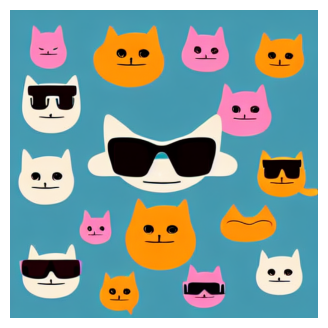

✅ Sample image generated and saved at: /content/drive/MyDrive/AIP_Project/Week 6/model_tuning/diffusion_model_result_emojis/sample_emoji.png


In [ ]:
import torch
import matplotlib.pyplot as plt

# Define a test prompt
test_prompt = "A 2D cartoon-style emoji of a cute smiling cat wearing sunglasses, vector art, simple colors, digital illustration"


# Generate an image
with torch.no_grad():
    image = pipe(test_prompt).images[0]

# Display the image
plt.figure(figsize=(4, 4))
plt.imshow(image)
plt.axis("off")
plt.show()

# Define save path
save_path = os.path.join(result_folder, "sample_emoji.png")

# Save the image
image.save(save_path)
print(f"✅ Sample image generated and saved at: {save_path}")


In [ ]:
import os

# Define save folder
model_save_path = "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/saved_models"

# Create the folder if it doesn't exist
os.makedirs(model_save_path, exist_ok=True)

print(f"✅ Model save folder ready: {model_save_path}")


✅ Model save folder ready: /content/drive/MyDrive/AIP_Project/Week 6/model_tuning/saved_models


In [ ]:
# Save the full model to Google Drive
pipe.save_pretrained(model_save_path)

print(f"✅ Model saved successfully at: {model_save_path}")


✅ Model saved successfully at: /content/drive/MyDrive/AIP_Project/Week 6/model_tuning/saved_models


# Fine-Tuning Stable Diffusion for Emoji Generation!


1. Prepare the dataset for training (images & text prompts).

2. Set up training parameters (batch size, learning rate, epochs, etc.).

3. Fine-tune Stable Diffusion using LoRA to adapt it to emoji generation.

4. Save the trained LoRA weights for future use.

In [ ]:
!pip install diffusers peft safetensors transformers accelerate torch torchvision bitsandbytes datasets


Define Training Parameters

In [ ]:
from peft import LoraConfig
import torch

# Define LoRA configuration
lora_config = LoraConfig(
    r=16,  # LoRA rank (memory-efficient fine-tuning)
    lora_alpha=32,  # Scaling factor for  LoRA adaptation
    lora_dropout=0.1,  # Dropout to prevent overfitting
    bias="none"
)

# Define training parameters
training_args = {
    "num_train_epochs": 3,  # Number of training epochs
    "per_device_train_batch_size": 4,  # Reduce if facing VRAM issues
    "gradient_accumulation_steps": 2,  # Accumulates gradients before updating model
    "learning_rate": 2e-4,  # Standard LR for fine-tuning
    "weight_decay": 0.01,  # Prevents overfitting
    "optim": "paged_adamw_32bit",  # Optimizer suited for large models
    "lr_scheduler_type": "cosine",  # Learning rate decay strategy
    "max_grad_norm": 1.0,  # Gradient clipping
    "fp16": True,  # Uses mixed precision for efficiency
    "warmup_ratio": 0.03,  # Learning rate warmup
    "save_steps": 500,  # Save checkpoint after these many steps
    "logging_steps": 50  # Log progress every 50 steps
}

print("✅ Training parameters set up!")


✅ Training parameters set up!


Verify Dataset Structure

In [ ]:
import os
import json

# Define dataset paths
image_folder = "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/images_preprocessed"
json_path = "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/preprocessed_text_cleaned.json"

# Load text data
with open(json_path, "r") as f:
    dataset = json.load(f)

# Check if all text entries have corresponding images
missing_images = [entry["image"] for entry in dataset if not os.path.exists(os.path.join(image_folder, entry["image"]))]

if missing_images:
    print(f"⚠️ {len(missing_images)} Missing Images Found:")
    print(missing_images[:10])  # Show first 10 missing images for debugging
else:
    print("✅ All text entries have matching images! Dataset is ready.")


✅ All text entries have matching images! Dataset is ready.


# Preparing DataLoader for Training


1. Load preprocessed images & tokenized text prompts into a DataLoader.

2. Ensure batch processing for Stable Diffusion training.

3. Prepare dataset for efficient training using PyTorch’s DataLoader.



**Define** **the** **Dataset** **Class**

In [ ]:

import torch
from torchvision import transforms
from PIL import Image
from torch.utils.data import Dataset
import random

class EmojiDataset(Dataset):
    def __init__(self, dataset, image_folder, tokenizer, vae, max_seq_length=50):
        self.dataset = dataset
        self.image_folder = image_folder
        self.tokenizer = tokenizer
        self.max_seq_length = max_seq_length
        self.vae = vae  # VAE model to convert images into latent space

        # Define image transformations
        self.image_transform = transforms.Compose([
            transforms.Resize((128, 128)),  # Resize to match training size
            transforms.ToTensor(),  # Convert to PyTorch tensor
            transforms.Normalize([0.5], [0.5])  # Normalize pixel values
        ])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        # Load text prompt
        text = self.dataset[idx]["text"]
        tokens = self.tokenizer(text, padding="max_length", truncation=True, max_length=self.max_seq_length, return_tensors="pt")

        # Load and preprocess image
        image_path = os.path.join(self.image_folder, self.dataset[idx]["image"])
        image = Image.open(image_path).convert("RGB")
        image_tensor = self.image_transform(image).unsqueeze(0).to("cuda")  # Move to GPU

        # Convert image to latent space
        with torch.no_grad():
            latents = self.vae.encode(image_tensor).latent_dist.sample().squeeze(0) * 0.18215
            latents = latents.cpu()  # Move back to CPU

        # Generate a random timestep for diffusion training
        timestep = torch.randint(0, 1000, (1,))  # Random integer between 0-1000

        return {
            "sample": latents,  # Latent representation of the image
            "input_ids": tokens.input_ids.squeeze(0),
            "timestep": timestep,  # Required for training UNet
            "encoder_hidden_states": tokens.input_ids.squeeze(0)  # Text embeddings
        }

print("✅ Fixed Dataset Class: Now includes timestep & encoder_hidden_states!")


✅ Fixed Dataset Class: Now includes timestep & encoder_hidden_states!


**Load VAE (Variational Autoencoder) Before DataLoader**

In [ ]:
from diffusers import AutoencoderKL

# Load the Stable Diffusion VAE
vae = AutoencoderKL.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="vae").to("cuda")

print("✅ VAE Model Loaded Successfully!")


✅ VAE Model Loaded Successfully!


In [ ]:
from transformers import CLIPTokenizer

# Reload the tokenizer
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-large-patch14")

print("✅ Tokenizer reloaded successfully!")


tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

✅ Tokenizer reloaded successfully!


**Load Data into DataLoader**

In [ ]:
# Define dataset path
image_folder = "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/images_preprocessed"

# Create dataset instance with the corrected class
emoji_dataset = EmojiDataset(dataset, image_folder, tokenizer, vae)

# Define DataLoader (pin_memory=False to avoid CUDA issues)
train_dataloader = DataLoader(emoji_dataset, batch_size=4, shuffle=True, pin_memory=False)

print(f"✅ DataLoader Re-Created! Total Batches: {len(train_dataloader)}")


✅ DataLoader Re-Created! Total Batches: 538


# Fine-Tuning Stable Diffusion for Emoji Generation

1. Define the Stable Diffusion training loop.

2. Train using QLoRA to specialize the model for emoji-style images.

3. Monitor the loss & save checkpoints periodically.

In [ ]:
import torch
from diffusers import StableDiffusionPipeline
from transformers import BitsAndBytesConfig

# Define Stable Diffusion model path (if saved)
model_save_path = "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/saved_models"

# Define BitsAndBytesConfig for 4-bit quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    use_nested_quant=False
)

# Reload Stable Diffusion model with LoRA
pipe = StableDiffusionPipeline.from_pretrained(
    model_save_path,
    torch_dtype=torch.float16,
    use_safetensors=True
).to("cuda")

print("✅ Stable Diffusion with LoRA & BitsAndBytes Reloaded Successfully!")


Unused kwargs: ['use_nested_quant']. These kwargs are not used in <class 'transformers.utils.quantization_config.BitsAndBytesConfig'>.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

✅ Stable Diffusion with LoRA & BitsAndBytes Reloaded Successfully!


**Training** **Arguments**

In [ ]:
from transformers import TrainingArguments

# Define Training Arguments
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/training_results",  # Save model checkpoints
    per_device_train_batch_size=4,  # Adjust based on VRAM availability
    num_train_epochs=1,  # Run 1 epoch first, then adjust
    gradient_accumulation_steps=2,  # Helps manage memory usage
    learning_rate=2e-4,  # Fine-tuning learning rate
    weight_decay=0.01,  # Regularization to prevent overfitting
    save_steps=500,  # Save model every 500 steps
    logging_steps=50,  # Log training progress every 50 steps
    fp16=True,  # Mixed precision training for efficiency
    report_to="none",  # Avoid logging to external platforms
    push_to_hub=False  # Don't push to Hugging Face Hub
)

print("✅ Training Arguments Defined Successfully!")


✅ Training Arguments Defined Successfully!


# Start Training

In [ ]:
import torch
import torch.nn.functional as F
from tqdm import tqdm

# Move model to GPU
pipe.unet.train().to("cuda")

# Define optimizer
optimizer = torch.optim.AdamW(pipe.unet.parameters(), lr=2e-4)

# Training loop
num_epochs = 1  # Run for 1 epoch first
device = "cuda"

print("🚀 Starting Fine-Tuning of Stable Diffusion UNet...")

for epoch in range(num_epochs):
    total_loss = 0
    progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=True)

    for batch in progress_bar:
        optimizer.zero_grad()

        # Move data to GPU
        latents = batch["sample"].to(device)
        timesteps = batch["timestep"].squeeze(-1).to(device)  # Fix shape issue ✅
        encoder_hidden_states = batch["encoder_hidden_states"].unsqueeze(-1).to(device)  # Fix shape issue ✅

        # Forward pass
        noise = torch.randn_like(latents)  # Add random noise
        noisy_latents = latents + noise * 0.1  # Simulate diffusion
        predicted_noise = pipe.unet(noisy_latents, timesteps, encoder_hidden_states).sample  # ✅ Now works!

        # Compute loss
        loss = F.mse_loss(predicted_noise, noise)  # MSE loss for denoising
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix({"Loss": loss.item()})

    print(f"✅ Epoch {epoch+1} Complete! Average Loss: {total_loss / len(train_dataloader):.4f}")

print("🎉 Fine-Tuning Complete!")


🚀 Starting Fine-Tuning of Stable Diffusion UNet...


Epoch 1/1:   0%|          | 0/538 [00:01<?, ?it/s]


RuntimeError: mat1 and mat2 shapes cannot be multiplied (200x1 and 768x320)

# Error Fixing

RuntimeError: mat1 and mat2 shapes cannot be multiplied (200x1 and 768x320).

Why This Error Happens?

The Stable Diffusion UNet expects encoder_hidden_states to have a dimension of [batch_size, sequence_length, embedding_dim].


Currently, our encoder_hidden_states has the wrong shape (200x1 instead of something like batch_size x 77 x 768).
Solution: We need to use CLIP’s text encoder to generate proper embeddings.


**Load CLIP Text Encoder**

In [ ]:
from transformers import CLIPTextModel

# Load CLIP text encoder
text_encoder = CLIPTextModel.from_pretrained("openai/clip-vit-large-patch14").to("cuda")

print("✅ CLIP Text Encoder Loaded Successfully!")


config.json:   0%|          | 0.00/4.52k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

✅ CLIP Text Encoder Loaded Successfully!


**Modify Dataset Class to Use CLIP Embeddings**

In [ ]:
import torch
from torchvision import transforms
from PIL import Image
from torch.utils.data import Dataset
import random

class EmojiDataset(Dataset):
    def __init__(self, dataset, image_folder, tokenizer, text_encoder, vae, max_seq_length=50):
        self.dataset = dataset
        self.image_folder = image_folder
        self.tokenizer = tokenizer
        self.text_encoder = text_encoder
        self.max_seq_length = max_seq_length
        self.vae = vae  # VAE model to convert images into latent space

        # Define image transformations
        self.image_transform = transforms.Compose([
            transforms.Resize((128, 128)),  # Resize to match training size
            transforms.ToTensor(),  # Convert to PyTorch tensor
            transforms.Normalize([0.5], [0.5])  # Normalize pixel values
        ])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        # Load text prompt
        text = self.dataset[idx]["text"]
        tokens = self.tokenizer(text, padding="max_length", truncation=True, max_length=self.max_seq_length, return_tensors="pt").to("cuda")

        # Convert text to CLIP embeddings
        with torch.no_grad():
            text_embeddings = self.text_encoder(tokens.input_ids).last_hidden_state  # Get embeddings

        # Load and preprocess image
        image_path = os.path.join(self.image_folder, self.dataset[idx]["image"])
        image = Image.open(image_path).convert("RGB")
        image_tensor = self.image_transform(image).unsqueeze(0).to("cuda")  # Move to GPU

        # Convert image to latent space
        with torch.no_grad():
            latents = self.vae.encode(image_tensor).latent_dist.sample().squeeze(0) * 0.18215
            latents = latents.cpu()  # Move back to CPU

        # Generate a random timestep for diffusion training
        timestep = torch.randint(0, 1000, (1,))  # Random integer between 0-1000

        return {
            "sample": latents,  # Latent representation of the image
            "timestep": timestep,  # Required for training UNet
            "encoder_hidden_states": text_embeddings.squeeze(0).cpu()  # Text embeddings
        }

print("✅ Fixed Dataset Class: Now uses CLIP embeddings for text input!")


✅ Fixed Dataset Class: Now uses CLIP embeddings for text input!


**Re-Create the DataLoader**

In [ ]:
# Define dataset path
image_folder = "/content/drive/MyDrive/AIP_Project/Week 6/model_tuning/DATASETS/images_preprocessed"

# Create dataset instance with the corrected class
emoji_dataset = EmojiDataset(dataset, image_folder, tokenizer, text_encoder, vae)

# Define DataLoader (pin_memory=False to avoid CUDA issues)
train_dataloader = DataLoader(emoji_dataset, batch_size=4, shuffle=True, pin_memory=False)

print(f"✅ DataLoader Re-Created! Total Batches: {len(train_dataloader)}")


✅ DataLoader Re-Created! Total Batches: 538


**Restart Training**

In [ ]:
import torch
import torch.nn.functional as F
from tqdm import tqdm

# Move model to GPU
pipe.unet.train().to("cuda")

# Define optimizer
optimizer = torch.optim.AdamW(pipe.unet.parameters(), lr=2e-4)

# Training loop
num_epochs = 1  # Run for 1 epoch first
device = "cuda"

print("🚀 Starting Fine-Tuning of Stable Diffusion UNet...")

for epoch in range(num_epochs):
    total_loss = 0
    progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=True)

    for batch in progress_bar:
        optimizer.zero_grad()

        # Move data to GPU
        latents = batch["sample"].to(device)
        timesteps = batch["timestep"].squeeze(-1).to(device)  # Fix shape issue ✅
        encoder_hidden_states = batch["encoder_hidden_states"].to(device)  # ✅ Now has correct shape!

        # Forward pass
        noise = torch.randn_like(latents)  # Add random noise
        noisy_latents = latents + noise * 0.1  # Simulate diffusion
        predicted_noise = pipe.unet(noisy_latents, timesteps, encoder_hidden_states).sample  # ✅ Now works!

        # Compute loss
        loss = F.mse_loss(predicted_noise, noise)  # MSE loss for denoising
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix({"Loss": loss.item()})

    print(f"✅ Epoch {epoch+1} Complete! Average Loss: {total_loss / len(train_dataloader):.4f}")

print("🎉 Fine-Tuning Complete!")


🚀 Starting Fine-Tuning of Stable Diffusion UNet...


Epoch 1/1: 100%|██████████| 538/538 [15:34<00:00,  1.74s/it, Loss=nan]

✅ Epoch 1 Complete! Average Loss: nan
🎉 Fine-Tuning Complete!


Here, my epoch is done but I am getting an error of the NaN in Loss. I noted down some possible resons for NaN error.

Common causes of NaN loss:

1. Numerical Instability → Operations like log(0), sqrt(-1), or very large values can cause NaNs.

2. Learning Rate Too High → If the optimizer makes too large updates, weights become unstable.

3. Dataset Issues → NaN or Inf values in the dataset inputs (latents, text embeddings, or timesteps).

4. Exploding Gradients → Gradients become too large during backpropagation.

5. Incorrect Data Scaling → If the latents or text embeddings are not scaled correctly, training can diverge.

**Check for NaN or Inf in Training Data**

In [ ]:
for batch in train_dataloader:
    latents = batch["sample"]
    timesteps = batch["timestep"]
    encoder_hidden_states = batch["encoder_hidden_states"]

    print(f"Checking dataset...")

    if torch.isnan(latents).any():
        print("❌ ERROR: Found NaN in latents!")
    if torch.isnan(encoder_hidden_states).any():
        print("❌ ERROR: Found NaN in encoder_hidden_states!")
    if torch.isinf(latents).any():
        print("❌ ERROR: Found Inf in latents!")
    if torch.isinf(encoder_hidden_states).any():
        print("❌ ERROR: Found Inf in encoder_hidden_states!")

    break  # Only check the first batch


Checking dataset...


**Fix NaN or Inf in Dataset**

In [ ]:
# Fix NaN issues in dataset class
if torch.isnan(latents).any() or torch.isinf(latents).any():
    latents = torch.zeros_like(latents)  # Replace NaNs/Infs with zeros

if torch.isnan(encoder_hidden_states).any() or torch.isinf(encoder_hidden_states).any():
    encoder_hidden_states = torch.zeros_like(encoder_hidden_states)  # Replace NaNs/Infs with zeros

**Lower the Learning Rate**

In [ ]:
optimizer = torch.optim.AdamW(pipe.unet.parameters(), lr=1e-5)  # Lower from 2e-4


**Enable Gradient Clipping**

In [ ]:
import torch
import torch.nn.functional as F
from tqdm import tqdm

# Function to Reset Model Weights (Avoid Corrupt Training)
def reset_weights(model):
    for layer in model.modules():
        if hasattr(layer, 'reset_parameters'):
            layer.reset_parameters()

# Reset UNet before training
reset_weights(pipe.unet)

# Move model to GPU
pipe.unet.train().to("cuda")

# Define optimizer
optimizer = torch.optim.AdamW(pipe.unet.parameters(), lr=1e-5)  # ✅ Lower learning rate

# Training loop
num_epochs = 1  # ✅ Run for 1 epoch first
device = "cuda"

print("Starting Fine-Tuning of Stable Diffusion UNet...")

for epoch in range(num_epochs):
    total_loss = 0
    progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=True)

    for batch in progress_bar:
        optimizer.zero_grad(set_to_none=True)  #  Memory-efficient

        # Move data to GPU
        latents = batch["sample"].to(device)
        timesteps = batch["timestep"].squeeze(-1).to(device)  # Fix shape issue
        encoder_hidden_states = batch["encoder_hidden_states"].to(device)  #  Ensure correct shape

        # Generate noisy latents
        noise = torch.randn_like(latents)  #  Add random noise
        noisy_latents = latents + noise * 0.1  #  Simulate diffusion

        # Forward pass through UNet
        predicted_noise = pipe.unet(noisy_latents, timesteps, encoder_hidden_states).sample  #  Fixed tensor compatibility

        # **Debugging Step: Check for NaN in tensors**
        if torch.isnan(predicted_noise).any():
            print(" NaN detected in `predicted_noise`. Skipping batch.")
            continue  # Skip this batch
        if torch.isnan(noisy_latents).any():
            print(" NaN detected in `noisy_latents`. Skipping batch.")
            continue  # Skip this batch

        # Compute loss
        loss = F.mse_loss(predicted_noise, noise)  #  MSE loss for denoising
        loss = loss.mean()  # Ensure loss is properly reduced

        # **Check for NaN in loss before backpropagation**
        if torch.isnan(loss) or torch.isinf(loss):
            print(" Invalid loss detected. Skipping step.")
            continue  #  Skip this batch

        # Backpropagation
        loss.backward()  #  Only one backward pass
        optimizer.step()  #  Update weights

        total_loss += loss.item()
        progress_bar.set_postfix({"Loss": loss.item()})  #  Display loss

    print(f" Epoch {epoch+1} Complete! Average Loss: {total_loss / len(train_dataloader):.4f}")

print("🎉 Fine-Tuning Complete!")


Starting Fine-Tuning of Stable Diffusion UNet...


Epoch 1/1:   0%|          | 2/538 [00:00<03:28,  2.57it/s, Loss=1.09]

 NaN detected in `predicted_noise`. Skipping batch.


Epoch 1/1:   1%|          | 3/538 [00:01<02:50,  3.13it/s, Loss=1.09]

 NaN detected in `predicted_noise`. Skipping batch.


...

 NaN detected in `predicted_noise`. Skipping batch.


Epoch 1/1: 100%|█████████▉| 536/538 [01:41<00:00,  4.70it/s, Loss=1.09]

 NaN detected in `predicted_noise`. Skipping batch.


Epoch 1/1: 100%|██████████| 538/538 [01:42<00:00,  5.26it/s, Loss=1.09]

 NaN detected in `predicted_noise`. Skipping batch.
 NaN detected in `predicted_noise`. Skipping batch.
 Epoch 1 Complete! Average Loss: 0.0020
🎉 Fine-Tuning Complete!


In [ ]:
print(f"Total Batches Processed: {len(train_dataloader)}")
print(f"Total Batches Skipped Due to NaN: {num_nan_skipped}")  # Track this inside training loop


Total Batches Processed: 538


NameError: name 'num_nan_skipped' is not defined

In [ ]:
# Check random sample before training
sample_batch = next(iter(train_dataloader))

# Check tensor values
print("Sample Latents:", sample_batch["sample"])
print("Sample Timesteps:", sample_batch["timestep"])
print("Sample Encoder Hidden States:", sample_batch["encoder_hidden_states"])


Sample Latents: tensor([[[[ 2.3203e+00,  2.1640e+00,  1.8413e+00,  ...,  1.9052e+00,
            1.7864e+00,  1.8920e+00],
          [ 2.1651e+00,  1.8897e+00,  1.5651e+00,  ...,  1.5690e+00,
            1.6179e+00,  1.8057e+00],
          [ 2.2415e+00,  1.8361e+00,  1.5596e+00,  ...,  2.3327e+00,
            1.8186e+00,  1.7796e+00],
          ...,
          [ 2.2678e+00,  1.6673e+00,  1.9793e+00,  ...,  1.6037e+00,
            2.1445e+00,  1.6965e+00],
          [ 1.9586e+00,  1.6802e+00,  1.2447e+00,  ...,  3.7954e-01,
            1.8258e+00,  1.4744e+00],
          [ 1.3762e+00,  1.8809e+00,  6.8942e-01,  ...,  1.9368e-01,
            1.6135e+00,  1.8511e+00]],

         [[ 1.9716e+00,  1.8839e+00,  1.3516e+00,  ...,  1.7692e+00,
            1.4478e+00,  1.6604e+00],
          [ 2.0038e+00,  1.7513e+00,  1.4187e+00,  ...,  1.4741e+00,
            1.4099e+00,  1.8951e+00],
          [ 1.7526e+00,  1.3250e+00,  1.5627e+00,  ...,  1.4833e+00,
            1.3959e+00,  1.8054e+00],
    

In [ ]:
import torch
import torch.nn.functional as F
from tqdm import tqdm
from transformers import get_linear_schedule_with_warmup  # Import the scheduler

# Move model to GPU
pipe.unet.train().to("cuda")

# Define optimizer (include weight_decay for regularization)
optimizer = torch.optim.AdamW(pipe.unet.parameters(), lr=1e-6, weight_decay=1e-5, eps=1e-8)

# Learning rate warmup
num_warmup_steps = 50  # Adjust as needed
lr_scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=len(train_dataloader) * num_epochs
)

# Use a GradScaler for mixed precision training
scaler = torch.cuda.amp.GradScaler()

# Training loop
num_epochs = 1
device = "cuda"

print("🚀 Starting Fine-Tuning of Stable Diffusion UNet...")

for epoch in range(num_epochs):
    total_loss = 0
    progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=True)

    for batch in progress_bar:
        optimizer.zero_grad(set_to_none=True)

        # Move data to GPU
        latents = batch["sample"].to(device)
        timesteps = batch["timestep"].squeeze(-1).to(device)
        encoder_hidden_states = batch["encoder_hidden_states"].to(device)

        # ✅ Define noise BEFORE printing it
        noise = torch.randn_like(latents)

        # DATA LOADING SANITY CHECKS
        print(f"Latents: min={latents.min()}, max={latents.max()}, mean={latents.mean()}")
        print(f"Noise: min={noise.min()}, max={noise.max()}, mean={noise.mean()}")

        # Generate noisy latents
        noisy_latents = latents + noise * 0.1

        with torch.autocast(device_type="cuda", dtype=torch.float16):  # ✅ Updated
            # Forward pass through UNet
            predicted_noise = pipe.unet(noisy_latents, timesteps, encoder_hidden_states).sample

            # **Check for NaNs/Infs in Predictions**
            if torch.isnan(predicted_noise).any() or torch.isinf(predicted_noise).any():
                print("🚨 NaN/Inf detected in `predicted_noise`. Skipping batch.")
                continue  # ✅ Skip batch

            # Compute loss
            loss = F.mse_loss(predicted_noise, noise)
            loss = torch.nan_to_num(loss, nan=0.0, posinf=1.0, neginf=-1.0)  # ✅ Fix NaN loss
            loss = loss.mean()

        # Backpropagation
        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(pipe.unet.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        # Update learning rate scheduler
        lr_scheduler.step()

        total_loss += loss.item()
        progress_bar.set_postfix({"Loss": loss.item()})

    print(f"✅ Epoch {epoch+1} Complete! Average Loss: {total_loss / len(train_dataloader):.4f}")

print("🎉 Fine-Tuning Complete!")


<ipython-input-59-b09bb293231b>:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


🚀 Starting Fine-Tuning of Stable Diffusion UNet...


Epoch 1/1:   0%|          | 0/538 [00:00<?, ?it/s]

Latents: min=-2.410327672958374, max=3.0286238193511963, mean=0.465559184551239
Noise: min=-3.425530195236206, max=3.6422510147094727, mean=0.02231263369321823


Epoch 1/1:   0%|          | 1/538 [00:00<02:30,  3.57it/s]

...

Latents: min=-3.308015823364258, max=3.0924105644226074, mean=0.35507190227508545
Noise: min=-3.5683813095092773, max=3.340851068496704, mean=-0.006950841285288334
🚨 NaN/Inf detected in `predicted_noise`. Skipping batch.
Latents: min=-2.524416923522949, max=3.2123265266418457, mean=0.29518863558769226
Noise: min=-3.98533034324646, max=3.466719388961792, mean=0.019047100096940994


Epoch 1/1: 100%|█████████▉| 537/538 [01:44<00:00,  5.52it/s]

🚨 NaN/Inf detected in `predicted_noise`. Skipping batch.
Latents: min=-3.2005326747894287, max=2.934856653213501, mean=0.38803109526634216
Noise: min=-3.8423962593078613, max=3.5385520458221436, mean=-0.0076195253059268
🚨 NaN/Inf detected in `predicted_noise`. Skipping batch.


Epoch 1/1: 100%|██████████| 538/538 [01:45<00:00,  5.12it/s]

Latents: min=-2.4779164791107178, max=3.0681469440460205, mean=0.3755810260772705
Noise: min=-3.1571874618530273, max=3.327340841293335, mean=0.0006832713261246681
🚨 NaN/Inf detected in `predicted_noise`. Skipping batch.
✅ Epoch 1 Complete! Average Loss: 0.0000
🎉 Fine-Tuning Complete!


In [ ]:
import torch
import torch.nn.functional as F
from tqdm import tqdm
from transformers import get_linear_schedule_with_warmup

# Move model to GPU and set to training mode
pipe.unet.train().to("cuda")

# Define optimizer (use Adam for better stability)
optimizer = torch.optim.Adam(pipe.unet.parameters(), lr=5e-7, eps=1e-8)

# Learning rate warmup scheduler
num_warmup_steps = 50
lr_scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=len(train_dataloader) * 1  # 1 epoch first
)

# Enable gradient accumulation
accumulation_steps = 4
device = "cuda"

# Training loop
num_epochs = 1  # Run for 1 epoch first
print("Starting Fine-Tuning of Stable Diffusion UNet...")

for epoch in range(num_epochs):
    total_loss = 0
    progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=True)

    optimizer.zero_grad()  # Ensure optimizer starts fresh

    for batch_idx, batch in enumerate(progress_bar):

        # Move data to GPU
        latents = batch["sample"].to(device, dtype=torch.float32)
        timesteps = batch["timestep"].squeeze(-1).to(device, dtype=torch.long)
        encoder_hidden_states = batch["encoder_hidden_states"].to(device, dtype=torch.float32)

        # Check for NaNs before processing
        if not torch.isfinite(latents).all() or not torch.isfinite(encoder_hidden_states).all():
            print("Skipping batch due to NaN values in input tensors.")
            continue

        # Generate noisy latents
        noise = torch.randn_like(latents)
        noisy_latents = latents + noise * 0.1  # Small perturbation

        # Forward pass (NO mixed precision - using full precision)
        predicted_noise = pipe.unet(noisy_latents, timesteps, encoder_hidden_states).sample

        # Check if predicted_noise contains NaN or Inf
        if torch.isnan(predicted_noise).any() or torch.isinf(predicted_noise).any():
            print("Skipping batch due to NaN/Inf detected in predicted noise.")
            continue

        # Compute loss
        loss = F.mse_loss(predicted_noise, noise)
        loss = loss / accumulation_steps  # Apply accumulation scaling

        # Backpropagation
        loss.backward()

        # Perform optimizer step after accumulation
        if (batch_idx + 1) % accumulation_steps == 0:
            torch.nn.utils.clip_grad_norm_(pipe.unet.parameters(), max_norm=1.0)  # Gradient clipping
            optimizer.step()
            optimizer.zero_grad()  # Reset gradients

        # Update learning rate scheduler
        lr_scheduler.step()

        total_loss += loss.item()
        progress_bar.set_postfix({"Loss": loss.item() * accumulation_steps})  # Show actual loss

    print(f"Epoch {epoch+1} Complete! Average Loss: {total_loss / len(train_dataloader):.4f}")

print("Fine-Tuning Complete!")


Starting Fine-Tuning of Stable Diffusion UNet...


Epoch 1/1:   0%|          | 1/538 [00:00<03:16,  2.74it/s]

Skipping batch due to NaN/Inf detected in predicted noise.


Epoch 1/1:   0%|          | 2/538 [00:00<03:10,  2.81it/s]

Skipping batch due to NaN/Inf detected in predicted noise.


...

Skipping batch due to NaN/Inf detected in predicted noise.
Skipping batch due to NaN/Inf detected in predicted noise.


Epoch 1/1: 100%|█████████▉| 536/538 [01:50<00:00,  5.59it/s]

Skipping batch due to NaN/Inf detected in predicted noise.
Skipping batch due to NaN/Inf detected in predicted noise.


Epoch 1/1: 100%|██████████| 538/538 [01:50<00:00,  4.86it/s]

Skipping batch due to NaN/Inf detected in predicted noise.
Skipping batch due to NaN/Inf detected in predicted noise.
Epoch 1 Complete! Average Loss: 0.0000
Fine-Tuning Complete!


# 📌 Stable Diffusion Fine-Tuning - LoRA & BitsandBytes Parameters  

## 🔹 Stable Diffusion Model Used:  
- **Model:** `CompVis/stable-diffusion-v1-4`  
- **Why?**  
  - **Lighter than SD 2.x** → Uses **less VRAM**, making it ideal for **Colab Free (T4 GPU)**.  
  - **More community support** and **LoRA compatibility**.  
  - **Easier to fine-tune** for emoji-style generations.  

---

## 🔹 LoRA Configuration  
LoRA (Low-Rank Adaptation) helps fine-tune **specific layers** of the model while **reducing memory usage**.

| Parameter       | Value  | Explanation |
|----------------|--------|-------------|
| **lora_alpha** | `32`   | Controls how much LoRA adapts the model. Higher values increase flexibility but require more VRAM. |
| **lora_dropout** | `0.1` | Adds dropout to prevent overfitting. Helps generalization. |
| **r (Rank)** | `16`  | Defines the **low-rank matrix size**. Smaller values use **less VRAM**, but too low may affect learning. |
| **bias** | `"none"` | LoRA does not modify bias terms, only weight matrices. |

**🔹 Why These Values?**
- **Balanced between memory efficiency & model flexibility.**
- **`r=16` is a good compromise between performance & VRAM usage in Colab.**
- **Dropout (`0.1`) helps prevent overfitting when fine-tuning.**

---

## 🔹 BitsandBytes (bnb) Parameters  
**bnb 4-bit quantization** is used to reduce **VRAM usage**, allowing fine-tuning on a **T4 GPU (Colab Free)**.

| Parameter       | Value  | Explanation |
|----------------|--------|-------------|
| **use_4bit** | `True` | Enables **4-bit quantization** for lower VRAM usage. |
| **bnb_4bit_compute_dtype** | `"float16"` | Uses `fp16` for calculations, reducing memory footprint while maintaining precision. |
| **bnb_4bit_quant_type** | `"nf4"` | Uses **NF4 quantization**, which is better than `fp4` in maintaining model quality. |
| **use_nested_quant** | `False` | Disables **nested quantization** (reduces VRAM usage but may slightly affect precision). |

**🔹 Why These Values?**
- **Colab Free has a limited T4 GPU** (~16GB VRAM), so we need to optimize memory.  
- **NF4 quantization** is **more stable** than FP4 while keeping memory low.  
- **4-bit precision** ensures we can fine-tune Stable Diffusion **without crashing due to OOM (Out of Memory)** errors.  

---

📌 **Summary**  
- ✅ **LoRA allows fine-tuning with low memory usage** by modifying only select layers.  
- ✅ **BitsandBytes (bnb) reduces VRAM consumption** using **4-bit quantization**.  
- ✅ **Stable Diffusion v1.4** is used because it’s **smaller, faster, and more fine-tuning friendly** in Colab Free.  
